## 1. Imports

On utilise :
- `pandas` pour manipuler les données ;
- `scikit-learn` pour les vectoriseurs, les modèles et l'évaluation ;
- `nltk` pour les **stopwords**, le **stemming** et la **lemmatisation** ;
- `zipfile` parce que le corpus est fourni dans une archive `.zip`.

### Pourquoi ajouter `nltk` ?
Parce qu'on veut comparer plusieurs niveaux de préprocessing :
1. **minimal** ;
2. **standard** ;
3. **agressif** (stopwords + stemming / lemmatisation).

# Classification des reviews de films — notebook de base

Ce notebook construit une **première baseline solide** pour la classification de sentiments sur les critiques de films (`pos` / `neg`).

## Objectifs
- charger les données d'entraînement ;
- faire une petite exploration du corpus ;
- appliquer un **préprocessing raisonnable** ;
- entraîner plusieurs **modèles de base** ;
- comparer les modèles avec les métriques demandées :
  - `accuracy`
  - `precision`
  - `recall`
  - `f1`
- justifier les choix de représentation et de modèles.

## Idée générale
Pour un premier projet TAL, on veut une approche :
1. **simple**
2. **reproductible**
3. **forte comme baseline**

C'est pour cela qu'on commence par des pipelines `vectoriseur + classifieur` avec `scikit-learn`, qui sont souvent très performants sur les données textuelles.

In [ ]:

import os
import re
import zipfile
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import wordpunct_tokenize

for resource in [
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


## 2. Chargement des données

Le corpus `movies1000.zip` contient deux sous-dossiers :
- `pos/` : reviews positives
- `neg/` : reviews négatives

Chaque fichier texte correspond à une review.

### Choix
On conserve ici le texte brut au chargement.  
Le préprocessing sera géré **ensuite dans des fonctions séparées**, ce qui permet de comparer plusieurs variantes sans recharger les données.

In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/projet tal/movies1000")

def load_movies_from_folder(data_dir: Path) -> pd.DataFrame:
    rows = []

    for label_folder, label in [("movies1000/pos", "P"), ("movies1000/neg", "N")]:
        folder = data_dir / label_folder
        for file_path in folder.glob("*.txt"):
            text = file_path.read_text(encoding="utf-8", errors="ignore")
            rows.append(
                {
                    "doc_id": file_path.name,
                    "label": label,
                    "text": text,
                }
            )

    df = pd.DataFrame(rows).sort_values("doc_id").reset_index(drop=True)
    return df

df = load_movies_from_folder(DATA_DIR)
print(df.shape)
df.head()


(2000, 3)


,doc_id,label,text
0,cv000_29416.txt,N,"plot : two teen couples go to a church party ,..."
1,cv000_29590.txt,P,films adapted from comic books have had plenty...
2,cv001_18431.txt,P,every now and then a movie comes along from a ...
3,cv001_19502.txt,N,the happy bastard's quick movie review \ndamn ...
4,cv002_15918.txt,P,you've got mail works alot better than it dese...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Exploration rapide du corpus

Avant de lancer les modèles, il faut regarder un minimum les données :
- taille du corpus ;
- équilibre des classes ;
- longueur des documents.

### Pourquoi ?
Parce que cela permet de vérifier si le dataset est équilibré.  
Si une classe domine fortement, l'accuracy peut être trompeuse et il faut alors :
- utiliser des métriques comme le **F1 macro** ;
- éventuellement tester `class_weight='balanced'`.

Ici on ajoute donc une **vérification explicite du déséquilibre** avant l'entraînement.


Nombre total de documents : 2000

Répartition des classes :
label
N    1000
P    1000
Name: count, dtype: int64

Taille classe majoritaire : 1000
Taille classe minoritaire : 1000
Ratio de déséquilibre majoritaire/minoritaire : 1.000
=> Les classes paraissent bien équilibrées. Pas de correction immédiate nécessaire.


n_chars                                   n_words                     \
           mean  median          std  min    max     mean median         std   
label                                                                          
N      3661.721  3455.5  1530.136157   91  11408  705.630  668.5  296.729759   
P      4124.283  3840.5  1849.144232  727  14957  787.051  731.5  352.799881   

                  
       min   max  
label             
N       17  2181  
P      130  2678

,n_chars,n_words
count,2000.000000,2000.00000
mean,3893.002000,746.34050
std,1712.425852,328.42529
min,91.000000,17.00000
25%,2737.750000,526.75000
50%,3622.500000,696.50000
75%,4720.250000,904.00000
max,14957.000000,2678.00000


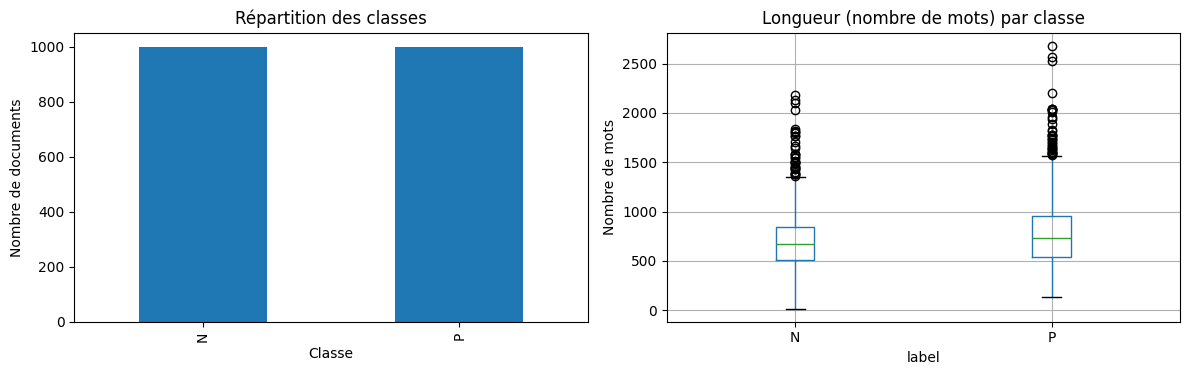

In [ ]:

print("Nombre total de documents :", len(df))
print("\nRépartition des classes :")
class_counts = df["label"].value_counts().sort_index()
print(class_counts)

minority = class_counts.min()
majority = class_counts.max()
imbalance_ratio = majority / minority if minority > 0 else np.inf

print(f"\nTaille classe majoritaire : {majority}")
print(f"Taille classe minoritaire : {minority}")
print(f"Ratio de déséquilibre majoritaire/minoritaire : {imbalance_ratio:.3f}")

if imbalance_ratio <= 1.2:
    print("=> Les classes paraissent bien équilibrées. Pas de correction immédiate nécessaire.")
elif imbalance_ratio <= 1.5:
    print("=> Léger déséquilibre. On surveille surtout precision / recall / f1_macro.")
else:
    print("=> Déséquilibre notable. Il faudra envisager un rééquilibrage ou class_weight='balanced'.")

df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

display(df.groupby("label")[["n_chars", "n_words"]].agg(["mean", "median", "std", "min", "max"]))
display(df[["n_chars", "n_words"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Répartition des classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de documents")

df.boxplot(column="n_words", by="label", ax=axes[1])
axes[1].set_title("Longueur (nombre de mots) par classe")
axes[1].set_ylabel("Nombre de mots")

plt.suptitle("")
plt.tight_layout()
plt.show()


## 4. Exemple de documents

Toujours utile pour vérifier :
- la langue du corpus ;
- la présence de ponctuation ;
- la forme générale du texte ;
- les artefacts éventuels.

In [ ]:

for label in ["P", "N"]:
    example = df[df["label"] == label].iloc[0]
    print(f"\n===== Exemple classe {label} | {example['doc_id']} =====")
    print(example["text"][:700], "...")


===== Exemple classe P | cv000_29590.txt =====
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . 
the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that con ...

===== Exemple classe N | cv000_29416.txt =====
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 


## 5. Préprocessing

Ici on définit maintenant **trois niveaux principaux** de préprocessing.

### V1. Préprocessing minimal
- passage en minuscules ;
- normalisation des espaces.

**Idée :** garder presque toute l'information.

### V2. Préprocessing standard
- minuscules ;
- suppression des accents ;
- suppression des URLs ;
- suppression de la ponctuation et des chiffres ;
- normalisation des espaces.

**Idée :** enlever une partie du bruit tout en conservant l'essentiel.

### V3. Préprocessing agressif
- basé sur la version standard ;
- tokenisation ;
- suppression des stopwords ;
- suppression des tokens très courts ;
- réduction morphologique.

Comme la réduction morphologique peut être faite de deux manières, on teste ici **deux sous-versions** :
- **V3-stem** : stemming avec `PorterStemmer`
- **V3-lemma** : lemmatisation avec `WordNetLemmatizer`

### Remarque sur les mots rares / trop fréquents
On ne les retire pas directement dans la fonction de préprocessing.  
On les filtre plutôt au niveau du vectoriseur avec `min_df` et `max_df`, ce qui est la manière la plus propre dans sklearn.


In [ ]:

def preprocess_minimal(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def strip_accents(text: str) -> str:
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", errors="ignore")

def preprocess_standard(text: str) -> str:
    text = text.lower()
    text = strip_accents(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

STOP_WORDS = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_aggressive_stem(text: str) -> str:
    text = preprocess_standard(text)
    tokens = wordpunct_tokenize(text)
    tokens = [
        tok for tok in tokens
        if tok.isalpha() and tok not in STOP_WORDS and len(tok) > 2
    ]
    tokens = [stemmer.stem(tok) for tok in tokens]
    return " ".join(tokens)

def preprocess_aggressive_lemma(text: str) -> str:
    text = preprocess_standard(text)
    tokens = wordpunct_tokenize(text)
    tokens = [
        tok for tok in tokens
        if tok.isalpha() and tok not in STOP_WORDS and len(tok) > 2
    ]
    tagged = pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in tagged]
    return " ".join(lemmas)

df["text_minimal"] = df["text"].apply(preprocess_minimal)
df["text_standard"] = df["text"].apply(preprocess_standard)
df["text_aggr_stem"] = df["text"].apply(preprocess_aggressive_stem)
df["text_aggr_lemma"] = df["text"].apply(preprocess_aggressive_lemma)

preview_cols = ["text", "text_minimal", "text_standard", "text_aggr_stem", "text_aggr_lemma"]
display(df[preview_cols].head(3))


,text,text_minimal,text_standard,text_aggr_stem,text_aggr_lemma
0,"plot : two teen couples go to a church party ,...","plot : two teen couples go to a church party ,...",plot two teen couples go to a church party dri...,plot two teen coupl church parti drink drive g...,plot two teen couple church party drink drive ...
1,films adapted from comic books have had plenty...,films adapted from comic books have had plenty...,films adapted from comic books have had plenty...,film adapt comic book plenti success whether s...,film adapt comic book plenty success whether s...
2,every now and then a movie comes along from a ...,every now and then a movie comes along from a ...,every now and then a movie comes along from a ...,everi movi come along suspect studio everi ind...,every movie come along suspect studio every in...


## 6. Découpage train / validation

On garde une partie des données pour une **évaluation finale locale**.  
Le reste servira à la validation croisée pendant la comparaison des modèles.

### Pourquoi `stratify` ?
On utilise `stratify=y` pour conserver la même proportion de classes dans `train` et `validation`.  
C'est particulièrement important dès qu'on veut éviter qu'un éventuel déséquilibre vienne biaiser l'évaluation.


In [ ]:

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

X_train_min, X_valid_min, _, _ = train_test_split(
    df["text_minimal"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

X_train_std, X_valid_std, _, _ = train_test_split(
    df["text_standard"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

X_train_stem, X_valid_stem, _, _ = train_test_split(
    df["text_aggr_stem"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

X_train_lemma, X_valid_lemma, _, _ = train_test_split(
    df["text_aggr_lemma"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)


## 7. Pipelines de base

On teste plusieurs baselines principales.

### 1. CountVectorizer + MultinomialNB
**Justification :**
- baseline classique en classification de texte ;
- très rapide ;
- simple à interpréter.

### 2. TF-IDF + LogisticRegression
**Justification :**
- excellente baseline pour le texte ;
- robuste ;
- compatible avec des vecteurs creux de grande dimension.

### 3. TF-IDF + LinearSVC
**Justification :**
- souvent très performant en classification textuelle ;
- bien adapté aux espaces de grande dimension.

### Filtrage des mots rares / trop fréquents
On l'intègre directement dans le vectoriseur avec :
- `min_df=2` : ignore les termes trop rares ;
- `max_df=0.95` : ignore les termes présents dans presque tous les documents.

Cela permet de limiter le bruit sans casser le pipeline.


In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipelines = {
    "NB_count_unigram": Pipeline([
        ("vect", CountVectorizer(lowercase=False, ngram_range=(1, 1), min_df=2, max_df=0.95)),
        ("clf", MultinomialNB()),
    ]),
    "LogReg_tfidf_12": Pipeline([
        ("vect", TfidfVectorizer(lowercase=False, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "LinearSVC_tfidf_12": Pipeline([
        ("vect", TfidfVectorizer(lowercase=False, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
    "LogReg_tfidf_12_balanced": Pipeline([
        ("vect", TfidfVectorizer(lowercase=False, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}


## 8. Évaluation par validation croisée

On compare d'abord les modèles sur les textes **prétraités**.

### Pourquoi `macro` pour precision / recall / f1 ?
La version `macro` donne le même poids à chaque classe.  
C'est utile pour éviter de se focaliser seulement sur la classe majoritaire, même si ici le corpus est presque équilibré.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label="P"),
    "recall": make_scorer(recall_score, pos_label="P"),
    "f1": make_scorer(f1_score, pos_label="P"),
}

def evaluate_cv(model_dict, X, y, cv, scoring):
    rows = []
    for name, model in model_dict.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"model": name}
        for metric_name in scoring.keys():
            values = scores[f"test_{metric_name}"]
            row[f"{metric_name}_mean"] = values.mean()
            row[f"{metric_name}_std"] = values.std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)


## 9. Comparaison : brut vs V1 vs V2 vs V3

On veut vérifier si le préprocessing aide réellement.

### Versions comparées
- `raw` : texte tel quel ;
- `v1_minimal` : minuscules + espaces ;
- `v2_standard` : nettoyage plus classique ;
- `v3_stem` : stopwords + stemming ;
- `v3_lemma` : stopwords + lemmatisation.

### Important
Le préprocessing agressif n'est pas toujours meilleur en sentiment analysis.  
Il peut réduire le bruit, mais aussi supprimer des indices utiles.  
On le teste donc expérimentalement au lieu de l'imposer.


In [ ]:

comparison_models = {
    "LogReg_tfidf_12": pipelines["LogReg_tfidf_12"],
    "LinearSVC_tfidf_12": pipelines["LinearSVC_tfidf_12"],
    "LogReg_tfidf_12_balanced": pipelines["LogReg_tfidf_12_balanced"],
}

results_cv_raw = evaluate_cv(comparison_models, df["text"], df["label"], cv, scoring)
results_cv_raw["text_version"] = "raw"

results_cv_min = evaluate_cv(comparison_models, df["text_minimal"], df["label"], cv, scoring)
results_cv_min["text_version"] = "v1_minimal"

results_cv_std = evaluate_cv(comparison_models, df["text_standard"], df["label"], cv, scoring)
results_cv_std["text_version"] = "v2_standard"

results_cv_stem = evaluate_cv(comparison_models, df["text_aggr_stem"], df["label"], cv, scoring)
results_cv_stem["text_version"] = "v3_stem"

results_cv_lemma = evaluate_cv(comparison_models, df["text_aggr_lemma"], df["label"], cv, scoring)
results_cv_lemma["text_version"] = "v3_lemma"

results_cv_all = pd.concat(
    [results_cv_raw, results_cv_min, results_cv_std, results_cv_stem, results_cv_lemma],
    ignore_index=True
).sort_values(["f1_mean", "accuracy_mean"], ascending=False)

display(results_cv_all)


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,text_version
6,LinearSVC_tfidf_12,0.8600,0.010954,0.855058,0.019835,0.868,0.022494,0.861094,0.010743,v2_standard
0,LinearSVC_tfidf_12,0.8590,0.009301,0.854682,0.017909,0.866,0.021541,0.859949,0.009316,raw
3,LinearSVC_tfidf_12,0.8590,0.009301,0.854682,0.017909,0.866,0.021541,0.859949,0.009316,v1_minimal
9,LinearSVC_tfidf_12,0.8430,0.015443,0.833702,0.014997,0.857,0.019647,0.845124,0.015635,v3_stem
12,LinearSVC_tfidf_12,0.8430,0.014265,0.836989,0.007604,0.852,0.032955,0.844101,0.016791,v3_lemma
13,LogReg_tfidf_12,0.8295,0.013454,0.829223,0.018776,0.831,0.033226,0.829519,0.015446,v3_lemma
14,LogReg_tfidf_12_balanced,0.8295,0.013454,0.829223,0.018776,0.831,0.033226,0.829519,0.015446,v3_lemma
7,LogReg_tfidf_12,0.8280,0.019519,0.824956,0.020616,0.833,0.024000,0.828816,0.019518,v2_standard
8,LogReg_tfidf_12_balanced,0.8280,0.019519,0.824956,0.020616,0.833,0.024000,0.828816,0.019518,v2_standard
10,LogReg_tfidf_12,0.8275,0.018439,0.826446,0.021682,0.830,0.032863,0.827741,0.019442,v3_stem


## 10. Choix du meilleur pipeline

On choisit le meilleur couple :
- **version de texte**
- **pipeline**
sur la base du `f1_macro` moyen en validation croisée.

### Pourquoi ?
Parce que le meilleur modèle dépend souvent du niveau de préprocessing.  
Ici, on ne suppose pas à l'avance que V3 sera meilleure que V1 ou V2.


In [ ]:

best_row = results_cv_all.iloc[0]
best_model_name = best_row["model"]
best_text_version = best_row["text_version"]
best_pipeline = pipelines[best_model_name]

print("Meilleur pipeline :", best_model_name)
print("Meilleure version du texte :", best_text_version)
display(best_row.to_frame().T)

version_to_train_valid = {
    "raw": (X_train_raw, X_valid_raw),
    "v1_minimal": (X_train_min, X_valid_min),
    "v2_standard": (X_train_std, X_valid_std),
    "v3_stem": (X_train_stem, X_valid_stem),
    "v3_lemma": (X_train_lemma, X_valid_lemma),
}

X_train_best, X_valid_best = version_to_train_valid[best_text_version]


Meilleur pipeline : LinearSVC_tfidf_12
Meilleure version du texte : v2_standard


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,text_version
6,LinearSVC_tfidf_12,0.86,0.010954,0.855058,0.019835,0.868,0.022494,0.861094,0.010743,v2_standard


## 11. Entraînement du meilleur modèle et évaluation sur le jeu de validation local

On entraîne maintenant le meilleur pipeline sur `train`, puis on évalue sur `valid`.

Les métriques affichées sont :
- accuracy ;
- precision_macro ;
- recall_macro ;
- f1_macro.

On garde `macro` pour donner le même poids aux deux classes, ce qui reste une bonne pratique même si le corpus semble équilibré.


In [ ]:

best_pipeline.fit(X_train_best, y_train)
y_pred = best_pipeline.predict(X_valid_best)

metrics_local = {
    "accuracy": accuracy_score(y_valid, y_pred),
    "precision_macro": precision_score(y_valid, y_pred, average="macro"),
    "recall_macro": recall_score(y_valid, y_pred, average="macro"),
    "f1_macro": f1_score(y_valid, y_pred, average="macro"),
}

pd.DataFrame([metrics_local]).T.rename(columns={0: "score"})


,score
accuracy,0.865000
precision_macro,0.865329
recall_macro,0.865000
f1_macro,0.864970


              precision    recall  f1-score   support

           N     0.8763    0.8500    0.8629       200
           P     0.8544    0.8800    0.8670       200

    accuracy                         0.8650       400
   macro avg     0.8653    0.8650    0.8650       400
weighted avg     0.8653    0.8650    0.8650       400



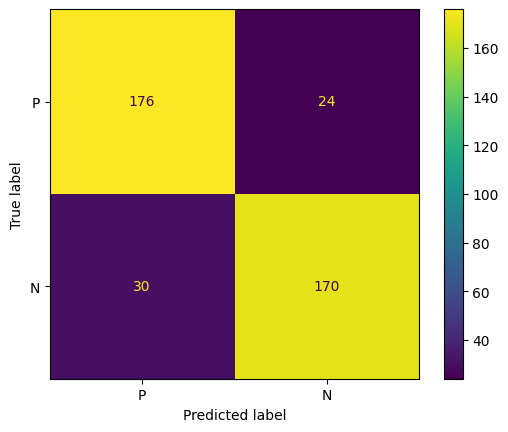

In [ ]:

print(classification_report(y_valid, y_pred, digits=4))

cm = confusion_matrix(y_valid, y_pred, labels=["P", "N"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["P", "N"])
disp.plot()
plt.show()

## 12. Analyse rapide des erreurs

Cette partie est utile dans un vrai projet, parce qu'elle permet de voir :
- quels documents sont mal classés ;
- si les erreurs viennent de la négation ;
- si certains textes sont ambigus ou ironiques ;
- si le préprocessing a supprimé trop d'information.

In [ ]:

valid_df = pd.DataFrame({
    "text": X_valid_best.values,
    "true_label": y_valid.values,
    "pred_label": y_pred,
})

errors = valid_df[valid_df["true_label"] != valid_df["pred_label"]].copy()
print("Nombre d'erreurs :", len(errors))
display(errors.head(10))


Nombre d'erreurs : 54


,text,true_label,pred_label
3,running time approximately hr mins reviewed by...,N,P
10,in the line of duty is the critically praised ...,N,P
11,take a number fill out a form and wait your tu...,P,N
22,the blair witch project was perhaps one of a k...,P,N
23,let's face it since waterworld floated by the ...,P,N
33,ok i admit it i find camp amusement with the s...,N,P
34,a couple of criminals mario van peebles and lo...,N,P
44,mandingo has traditionally been seen as one of...,N,P
48,warning may contain some mild spoilers and off...,P,N
66,the following review contains some harsh langu...,N,P


## 13. Conclusion intermédiaire

### Ce que montre ce notebook
- un pipeline BoW / TF-IDF est déjà une très bonne base ;
- `MultinomialNB` sert de baseline simple ;
- `LogisticRegression` et `LinearSVC` sont des choix solides pour des représentations creuses ;
- les **classes ont été vérifiées explicitement** avant l'entraînement ;
- le **préprocessing doit être testé**, pas imposé ;
- la version agressive (stopwords + stemming / lemmatisation) peut aider, mais elle peut aussi supprimer des indices utiles au sentiment.

### À retenir
Le meilleur choix est donc empirique : on garde la combinaison qui donne les meilleurs scores de validation, pas celle qui paraît la plus "propre" en théorie.


## 14. Cellule utile pour une future soumission

Quand le fichier de test sera disponible, il suffira de :
1. charger le test ;
2. appliquer **la même version de préprocessing que celle retenue** ;
3. prédire ;
4. sauvegarder un CSV avec une colonne de labels (`P` / `N`).

La cellule ci-dessous permet de choisir explicitement la fonction de préprocessing.


In [ ]:

PREPROCESSORS = {
    "raw": lambda x: x,
    "v1_minimal": preprocess_minimal,
    "v2_standard": preprocess_standard,
    "v3_stem": preprocess_aggressive_stem,
    "v3_lemma": preprocess_aggressive_lemma,
}

def build_submission(model, texts, text_version="v2_standard", out_path="submission-movie.csv"):
    preprocess_fn = PREPROCESSORS[text_version]
    texts_proc = pd.Series(texts).apply(preprocess_fn)
    preds = model.predict(texts_proc)
    sub = pd.DataFrame({"label": preds})
    sub.to_csv(out_path, index=False)
    return sub

# Exemple futur :
# test_texts = [...]
# submission = build_submission(best_pipeline, test_texts, text_version=best_text_version, out_path="submission-movie.csv")
# submission.head()


##**TEST**

In [ ]:
from pathlib import Path
import pandas as pd

TEST_FILE = Path("/content/drive/MyDrive/projet tal/testSentiment.txt")

def load_test_one_review_per_line(test_file: Path) -> pd.DataFrame:
    lines = test_file.read_text(encoding="utf-8", errors="ignore").splitlines()
    rows = []
    for i, line in enumerate(lines):
        line = line.strip()
        if line:
            rows.append({
                "doc_id": i,
                "text": line
            })
    return pd.DataFrame(rows)

test_df = load_test_one_review_per_line(TEST_FILE)
print(test_df.shape)
test_df.head()


(25648, 2)


,doc_id,text
0,0,Story of a man who has unnatural feelings for ...
1,1,Bromwell High is a cartoon comedy. It ran at t...
2,2,Airport '77 starts as a brand new luxury 747 p...
3,3,This film lacked something I couldn't put my f...
4,4,"Sorry everyone,,, I know this is supposed to b..."


In [ ]:
import pandas as pd

test_df["text_standard"] = test_df["text"].apply(preprocess_standard)

best_model = pipelines["LinearSVC_tfidf_12"]
best_model.fit(df["text_standard"], df["label"])

test_pred = best_model.predict(test_df["text_standard"])

print("Nombre de prédictions :", len(test_pred))
print("\nRépartition des classes prédites :")
print(pd.Series(test_pred).value_counts())

submission = pd.DataFrame({
    "label": test_pred
})

display(submission.head(10))

submission.to_csv("/content/drive/MyDrive/projet tal/submission-movie-test.csv", index=False)
print("\nFichier enregistré : /content/drive/MyDrive/projet tal/submission-movie-test.csv")


Nombre de prédictions : 25648

Répartition des classes prédites :
N    14698
P    10950
Name: count, dtype: int64


,label
0,P
1,P
2,N
3,N
4,N
5,P
6,N
7,P
8,P
9,N



Fichier enregistré : /content/drive/MyDrive/projet tal/submission-movie-test.csv


Amelioration **A**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_word_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

param_grid_word = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.95, 1.0],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.5, 1.0, 2.0],
}

grid_word = GridSearchCV(
    estimator=svm_word_pipeline,
    param_grid=param_grid_word,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_word.fit(df["text_standard"], df["label"])

print("Best word-level score:", grid_word.best_score_)
print("Best word-level params:", grid_word.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best word-level score: nan
Best word-level params: {'clf__C': 0.5, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}


**B**

In [ ]:
svm_char_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char")),
    ("clf", LinearSVC())
])

param_grid_char = {
    "tfidf__ngram_range": [(3, 5), (4, 6), (3, 6)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.5, 1.0, 2.0],
}

grid_char = GridSearchCV(
    estimator=svm_char_pipeline,
    param_grid=param_grid_char,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_char.fit(df["text_standard"], df["label"])

print("Best char-level score:", grid_char.best_score_)
print("Best char-level params:", grid_char.best_params_)

LSA / SVD **tronqué**